<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/new/kics_320km_edfa_raman_gn_ggn_reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KICS 320 km EDFA/Raman experiment: equation reproduction + GN/GGN screening

대상 논문: Bo-Hun Choi, **“320 km Optical Transmission using EDFA and Raman amplifier
for 10 Gbit/s 128 Channel DWDM Signals,”** J-KICS, vol. 34, no. 6, pp. 568–574, 2009.

- 원문: https://journal.kics.or.kr/digital-library/33081
- 재현 대상: Fig. 3, Fig. 7, Fig. 9, Fig. 10
- 논문 결과 좌표는 비교용으로만 사용하고, Fig. 3 모델 곡선은 논문의 cascade 식으로 계산합니다.

## 먼저 구분해야 할 물리량

- 논문 Fig. 3/9/10: OSA가 측정하거나 cascade noise-figure 식이 계산한 **optical OSNR**
- GN/GGN: 신호 대역 안의 비선형 간섭(NLI)을 포함한 **NLI-aware GSNR**

OSA의 interpolation 방식은 in-band NLI를 ASE와 분리해 직접 측정하지 못합니다.
또한 이 논문은 10 Gb/s NRZ IM-DD, NZ-DSF, DCF가 포함된 dispersion-managed loop이고,
저장소 GN/GGN은 rectangular Gaussian/coherent WDM 가정을 사용합니다.
따라서 GN/GGN 값은 논문의 OSNR를 대체하는 “정답”이 아니라 **적용성 검토용 screening estimate**입니다.

In [1]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.constants import c, h
try:
    from IPython.display import display
except ImportError:
    def display(obj):
        data = getattr(obj, "data", obj)
        if hasattr(data, "to_string"):
            print(data.to_string(index=False))
        else:
            print(data)

plt.rcParams.update({
    "figure.dpi": 125,
    "axes.grid": True,
    "grid.alpha": 0.30,
    "font.size": 10,
})

N_CH = 128
BIT_RATE_HZ = 10e9
EQUIV_SYMBOL_RATE_HZ = 10e9
SPACING_HZ = 50e9
SPAN_KM = 80.0
SPAN_LOSS_DB = 22.0
EDFA_NF_DB = 7.0
PIN_OLA_DBM = -15.0
OPTICAL_FILTER_HZ = 40e9  # not reported; declared within 50 GHz spacing
OSNR_REF_BW_HZ = 12.5e9
LAMBDA_M = 1550e-9

# Repository NZDSF preset; paper does not publish D and gamma.
NZDSF_D = 4.5
NZDSF_GAMMA = 1.5
NZDSF_ALPHA_DB_KM = SPAN_LOSS_DB / SPAN_KM

print(f"NZ-DSF screening parameters: alpha={NZDSF_ALPHA_DB_KM:.3f} dB/km, "
      f"D={NZDSF_D:.1f} ps/(nm km), gamma={NZDSF_GAMMA:.1f} 1/(W km)")

NZ-DSF screening parameters: alpha=0.275 dB/km, D=4.5 ps/(nm km), gamma=1.5 1/(W km)


## 1. Fig. 3 — cascade NF/Friis 식 기반 재현

논문은 EDFA NF=7 dB, Raman gain=0–6 dB를 사용합니다. Raman stage를 이상적인
low-noise pre-gain으로 근사하면 hybrid noise factor는

$$F_{hyb}=1+\frac{F_{EDFA}-1}{G_R}.$$

첫 증폭기는 모든 곡선에 공통이고 이후 $N-1$개 stage의 noise weight만 $F_{hyb}/F_{EDFA}$로
줄어든다고 두면

$$OSNR_N=OSNR_1-10\log_{10}\left[1+(N-1)F_{hyb}/F_{EDFA}\right].$$

식 (2)의 optical-filter bandwidth $B$는 원문에 수치가 없어 50 GHz channel spacing 안의
**40 GHz**로 선언했습니다. 50 GHz를 쓰면 모든 모델 곡선이 0.97 dB 낮아집니다.

 Raman gain [dB]  RMSE [dB]  Model OSNR at N=10 [dB]  Fig.3 at N=10 [dB]
               0       0.09                    20.90               21.03
               2       0.32                    22.24               21.92
               3       0.21                    22.84               22.61
               4       0.08                    23.37               23.30
               5       0.07                    23.85               23.93
               6       0.17                    24.27               24.54


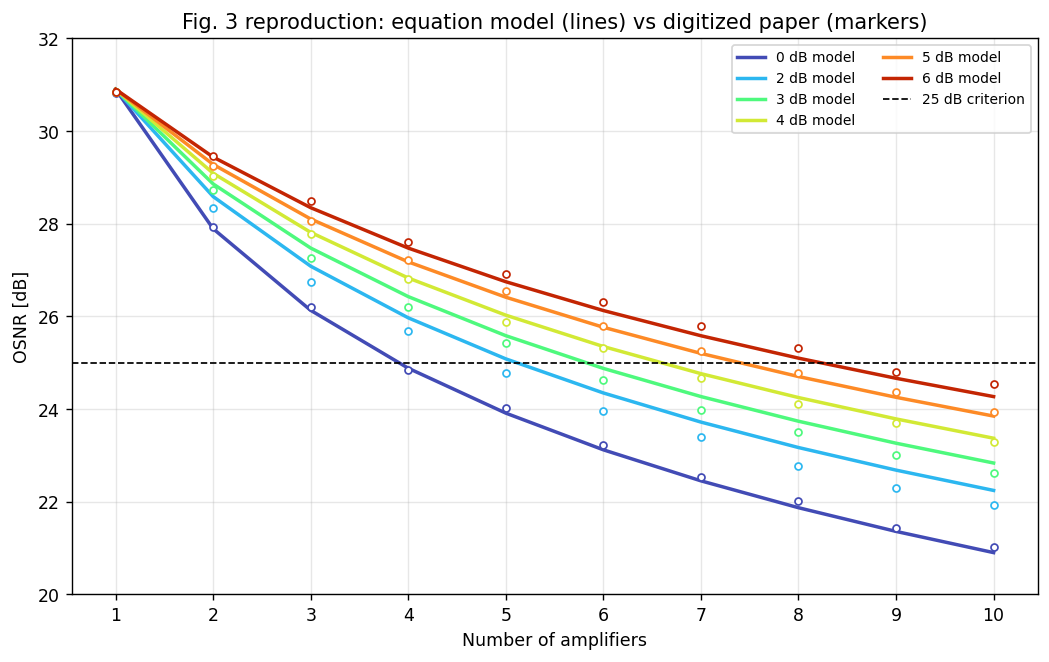

In [2]:
amp_count = np.arange(1, 11)
raman_gains_db = [0, 2, 3, 4, 5, 6]

# Digitized from Fig. 3 for validation only (about ±0.1 dB).
fig3_reference = {
    0: np.array([30.82, 27.92, 26.20, 24.85, 24.02, 23.22, 22.53, 22.01, 21.44, 21.03]),
    2: np.array([30.85, 28.33, 26.75, 25.68, 24.77, 23.96, 23.39, 22.78, 22.30, 21.92]),
    3: np.array([30.85, 28.73, 27.26, 26.20, 25.43, 24.62, 23.99, 23.50, 23.01, 22.61]),
    4: np.array([30.85, 29.04, 27.78, 26.80, 25.89, 25.31, 24.68, 24.11, 23.70, 23.30]),
    5: np.array([30.85, 29.24, 28.07, 27.21, 26.55, 25.80, 25.25, 24.77, 24.36, 23.93]),
    6: np.array([30.85, 29.47, 28.50, 27.61, 26.92, 26.32, 25.80, 25.31, 24.79, 24.54]),
}


def fig3_cascade_osnr_db(n_amp, raman_gain_db, filter_hz=OPTICAL_FILTER_HZ):
    nf = 10 ** (EDFA_NF_DB / 10)
    pin_w = 1e-3 * 10 ** (PIN_OLA_DBM / 10)
    nu = c / LAMBDA_M
    osnr1 = pin_w / (nf * h * nu * filter_hz)
    g_r = 10 ** (raman_gain_db / 10)
    f_hybrid = 1 + (nf - 1) / g_r
    noise_multiplier = 1 + (np.asarray(n_amp) - 1) * f_hybrid / nf
    return 10 * np.log10(osnr1 / noise_multiplier)


colors = plt.cm.turbo(np.linspace(0.08, 0.90, len(raman_gains_db)))
fig, ax = plt.subplots(figsize=(8.5, 5.4))
fig3_rows = []
for color, rg in zip(colors, raman_gains_db):
    model = fig3_cascade_osnr_db(amp_count, rg)
    ref = fig3_reference[rg]
    ax.plot(amp_count, model, color=color, lw=2, label=f"{rg} dB model")
    ax.plot(amp_count, ref, "o", color=color, ms=4, mfc="white")
    fig3_rows.append({"Raman gain [dB]": rg,
                      "RMSE [dB]": np.sqrt(np.mean((model - ref)**2)),
                      "Model OSNR at N=10 [dB]": model[-1],
                      "Fig.3 at N=10 [dB]": ref[-1]})
ax.axhline(25, color="black", ls="--", lw=1, label="25 dB criterion")
ax.set(xlabel="Number of amplifiers", ylabel="OSNR [dB]",
       title="Fig. 3 reproduction: equation model (lines) vs digitized paper (markers)")
ax.set_xticks(amp_count)
ax.set_ylim(20, 32)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()
display(pd.DataFrame(fig3_rows).round(2))

## 2. Fig. 7 — L-band EDFA 측정 spectrum

Fig. 7의 gain/NF 점을 디지타이즈한 결과입니다. 이 값은 뒤의 wavelength-dependent ASE 계산에
사용합니다. 논문 본문의 요약(1570–1602 nm 평균 gain 19.7 dB, gain variation 1.2 dB,
최대 NF 6.3 dB)과 비교합니다. 그래프 좌표 판독 오차는 약 ±0.1–0.2 dB입니다.

 Digitized mean gain [dB]  Digitized gain range [dB]  Digitized max NF [dB]  Paper mean gain [dB]  Paper gain variation [dB]  Paper max NF [dB]
                    19.36                       1.16                   6.37                  19.7                        1.2                6.3


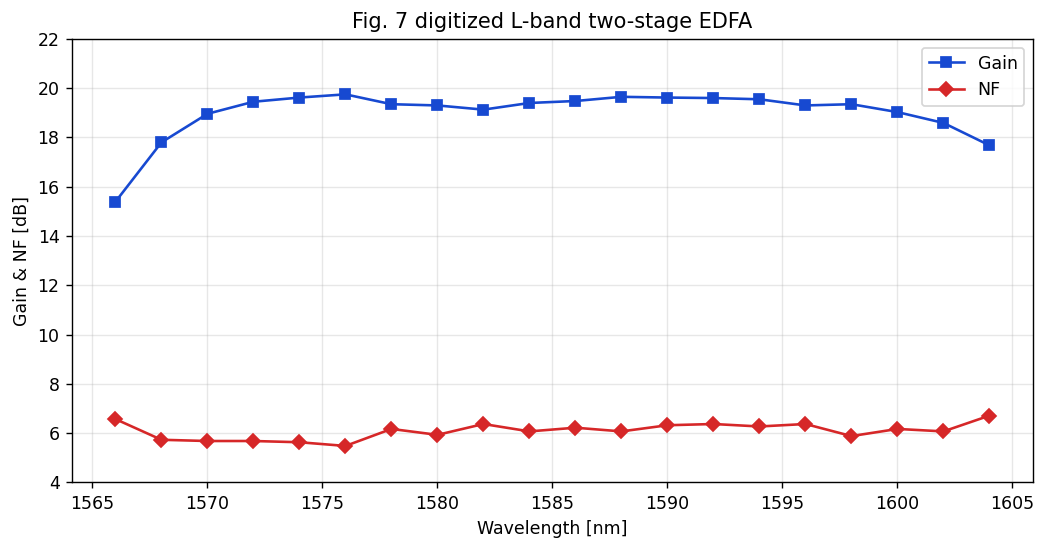

In [3]:
fig7_wavelength_nm = np.arange(1566, 1606, 2, dtype=float)
fig7_gain_db = np.array([15.39, 17.80, 18.96, 19.45, 19.62, 19.75, 19.35, 19.30, 19.13, 19.40,
                         19.48, 19.65, 19.62, 19.60, 19.55, 19.30, 19.35, 19.03, 18.59, 17.68])
fig7_nf_db = np.array([6.57, 5.73, 5.68, 5.68, 5.63, 5.48, 6.17, 5.93, 6.37, 6.07,
                       6.22, 6.07, 6.32, 6.37, 6.27, 6.37, 5.88, 6.17, 6.07, 6.71])

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(fig7_wavelength_nm, fig7_gain_db, "s-", color="#1749d1", label="Gain")
ax.plot(fig7_wavelength_nm, fig7_nf_db, "D-", color="#d62728", label="NF")
ax.set(xlabel="Wavelength [nm]", ylabel="Gain & NF [dB]",
       title="Fig. 7 digitized L-band two-stage EDFA")
ax.set_ylim(4, 22)
ax.legend()
plt.tight_layout()
plt.show()

in_reported_band = (fig7_wavelength_nm >= 1570) & (fig7_wavelength_nm <= 1602)
fig7_summary = pd.DataFrame([{
    "Digitized mean gain [dB]": fig7_gain_db[in_reported_band].mean(),
    "Digitized gain range [dB]": np.ptp(fig7_gain_db[in_reported_band]),
    "Digitized max NF [dB]": fig7_nf_db[in_reported_band].max(),
    "Paper mean gain [dB]": 19.7,
    "Paper gain variation [dB]": 1.2,
    "Paper max NF [dB]": 6.3,
}])
display(fig7_summary.round(2))

## 3. Fig. 9/10 — measured OSNR spectra와 ASE cascade 예측

논문의 0/80/140/200/260/320 km 곡선을 validation-only reference로 디지타이즈했습니다.
Algorithmic ASE model은 OBA 입력 −20 dBm/ch, OLA/OPA 입력 −15 dBm/ch, 0.1 nm(12.5 GHz)
OSNR reference bandwidth, wavelength-dependent NF를 사용합니다.

원문에 각 amplifier의 정확한 insertion loss, DCF loss, OPA operating point와 모든 gain ripple이
공개되지 않아, 이 단순 cascade는 320 km OSNR을 다소 낙관적으로 예측할 수 있습니다.

Band  Measured 320 km mean [dB]  ASE model 320 km mean [dB]  RMSE at 320 km [dB]
   C                      24.20                       26.52                 2.53
   L                      24.35                       27.88                 3.58


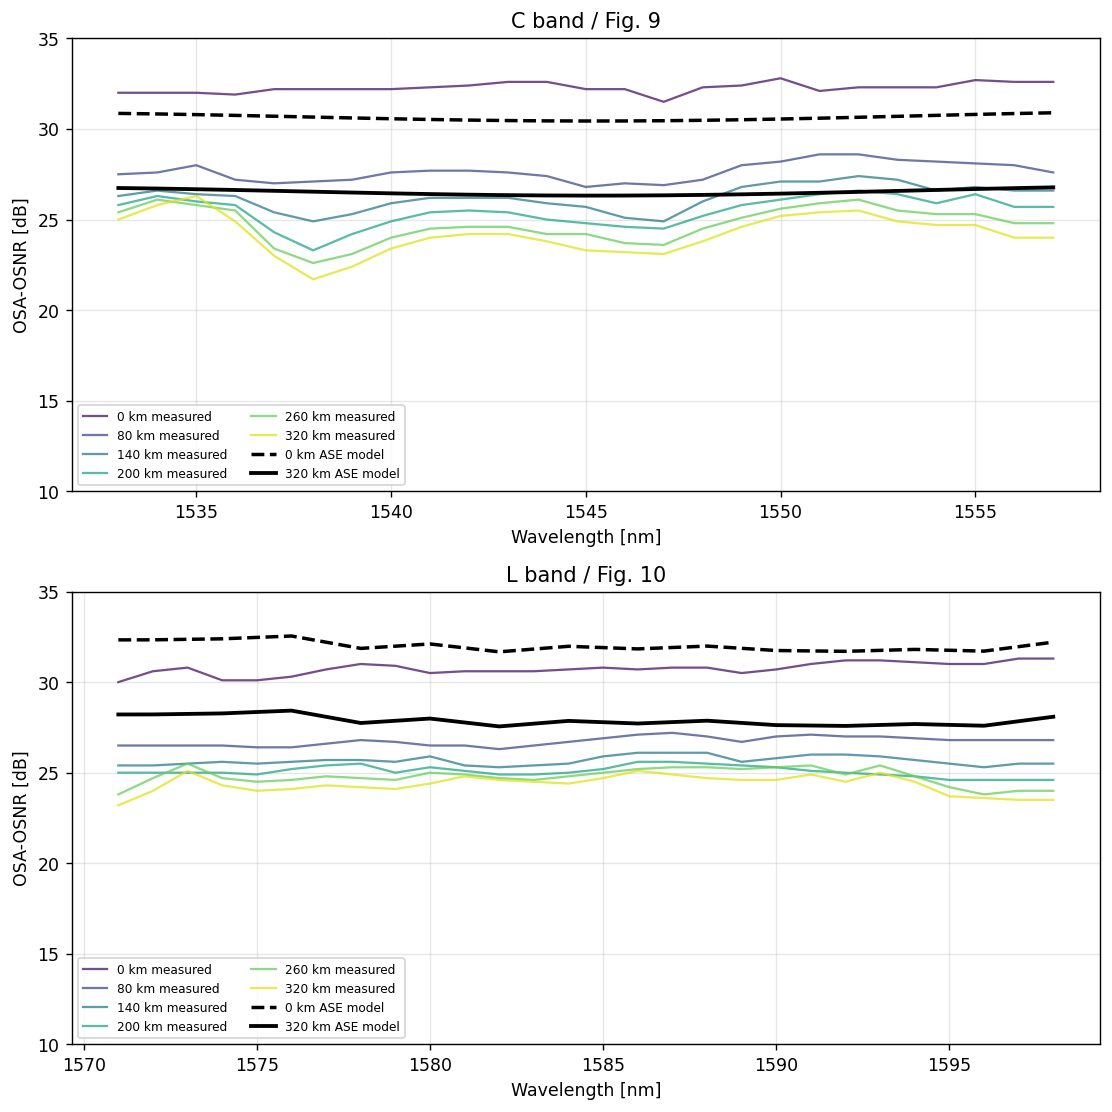

In [4]:
c_wl = np.arange(1533, 1558, dtype=float)
l_wl = np.arange(1571, 1599, dtype=float)
distances = [0, 80, 140, 200, 260, 320]

# Digitized Fig. 9 and Fig. 10 curves; reference only, not fitted by the model.
fig9_ref = {
    0: [32.0,32.0,32.0,31.9,32.2,32.2,32.2,32.2,32.3,32.4,32.6,32.6,32.2,32.2,31.5,32.3,32.4,32.8,32.1,32.3,32.3,32.3,32.7,32.6,32.6],
    80:[27.5,27.6,28.0,27.2,27.0,27.1,27.2,27.6,27.7,27.7,27.6,27.4,26.8,27.0,26.9,27.2,28.0,28.2,28.6,28.6,28.3,28.2,28.1,28.0,27.6],
    140:[26.3,26.6,26.4,26.3,25.4,24.9,25.3,25.9,26.2,26.2,26.2,25.9,25.7,25.1,24.9,26.0,26.8,27.1,27.1,27.4,27.2,26.6,26.8,26.6,26.6],
    200:[25.8,26.3,26.0,25.8,24.3,23.3,24.2,24.9,25.4,25.5,25.4,25.0,24.8,24.6,24.5,25.2,25.8,26.1,26.4,26.6,26.4,25.9,26.4,25.7,25.7],
    260:[25.4,26.1,25.8,25.5,23.4,22.6,23.1,24.0,24.5,24.6,24.6,24.2,24.2,23.7,23.6,24.5,25.1,25.6,25.9,26.1,25.5,25.3,25.3,24.8,24.8],
    320:[25.0,25.8,26.3,24.9,23.0,21.7,22.4,23.4,24.0,24.2,24.2,23.8,23.3,23.2,23.1,23.8,24.6,25.2,25.4,25.5,24.9,24.7,24.7,24.0,24.0],
}
fig10_ref = {
    0:[30.0,30.6,30.8,30.1,30.1,30.3,30.7,31.0,30.9,30.5,30.6,30.6,30.6,30.7,30.8,30.7,30.8,30.8,30.5,30.7,31.0,31.2,31.2,31.1,31.0,31.0,31.3,31.3],
    80:[26.5,26.5,26.5,26.5,26.4,26.4,26.6,26.8,26.7,26.5,26.5,26.3,26.5,26.7,26.9,27.1,27.2,27.0,26.7,27.0,27.1,27.0,27.0,26.9,26.8,26.8,26.8,26.8],
    140:[25.4,25.4,25.5,25.6,25.5,25.6,25.7,25.7,25.6,25.9,25.4,25.3,25.4,25.5,25.9,26.1,26.1,26.1,25.6,25.8,26.0,26.0,25.9,25.7,25.5,25.3,25.5,25.5],
    200:[25.0,25.0,25.0,25.0,24.9,25.2,25.4,25.5,25.0,25.3,25.1,24.9,24.9,25.0,25.2,25.6,25.6,25.5,25.4,25.3,25.1,25.0,24.9,24.8,24.6,24.6,24.6,24.6],
    260:[23.8,24.7,25.5,24.7,24.5,24.6,24.8,24.7,24.6,25.0,24.9,24.7,24.6,24.8,25.0,25.2,25.3,25.3,25.2,25.3,25.4,24.9,25.4,24.8,24.2,23.8,24.0,24.0],
    320:[23.2,24.0,25.1,24.3,24.0,24.1,24.3,24.2,24.1,24.4,24.8,24.6,24.5,24.4,24.7,25.1,24.9,24.7,24.6,24.6,24.9,24.5,25.0,24.5,23.7,23.6,23.5,23.5],
}
fig9_ref = {k: np.asarray(v, float) for k, v in fig9_ref.items()}
fig10_ref = {k: np.asarray(v, float) for k, v in fig10_ref.items()}


def c_band_nf_db(wavelength_nm):
    # Reported C-band maximum NF=7.5 dB; smooth bound-only model, not a fit to Fig. 9.
    x = (np.asarray(wavelength_nm) - 1530) / (1561 - 1530)
    return 7.0 + 0.5 * np.sin(np.pi * x) ** 2


def l_band_nf_db(wavelength_nm):
    return np.interp(wavelength_nm, fig7_wavelength_nm, fig7_nf_db)


def cascade_ase_osnr(wavelength_nm, nf_db, distance_km):
    wavelength_m = np.asarray(wavelength_nm) * 1e-9
    nu = c / wavelength_m
    nf = 10 ** (np.asarray(nf_db) / 10)
    p_oba = 1e-3 * 10 ** (-20 / 10)
    p_ola = 1e-3 * 10 ** (-15 / 10)
    snr_oba = p_oba / (nf * h * nu * OSNR_REF_BW_HZ)
    snr_line = p_ola / (nf * h * nu * OSNR_REF_BW_HZ)
    equivalent_spans = distance_km / SPAN_KM
    # OPA is counted only after transmission; exact operating point is not published.
    opa_weight = 1.0 if distance_km > 0 else 0.0
    return 10 * np.log10(1 / (1 / snr_oba + (equivalent_spans + opa_weight) / snr_line))


fig, axes = plt.subplots(2, 1, figsize=(9.0, 9.0))
summary_rows = []
for ax, wl, ref, nf_func, band in [
    (axes[0], c_wl, fig9_ref, c_band_nf_db, "C band / Fig. 9"),
    (axes[1], l_wl, fig10_ref, l_band_nf_db, "L band / Fig. 10"),
]:
    for d, color in zip(distances, plt.cm.viridis(np.linspace(0.05, 0.95, len(distances)))):
        ax.plot(wl, ref[d], color=color, lw=1.3, alpha=0.75, label=f"{d} km measured")
    model0 = cascade_ase_osnr(wl, nf_func(wl), 0)
    model320 = cascade_ase_osnr(wl, nf_func(wl), 320)
    ax.plot(wl, model0, "k--", lw=2.0, label="0 km ASE model")
    ax.plot(wl, model320, "k-", lw=2.2, label="320 km ASE model")
    ax.set(xlabel="Wavelength [nm]", ylabel="OSA-OSNR [dB]", title=band)
    ax.set_ylim(10, 35)
    ax.legend(ncol=2, fontsize=7)
    summary_rows.append({
        "Band": band.split()[0],
        "Measured 320 km mean [dB]": ref[320].mean(),
        "ASE model 320 km mean [dB]": model320.mean(),
        "RMSE at 320 km [dB]": np.sqrt(np.mean((model320 - ref[320])**2)),
    })
plt.tight_layout()
plt.show()
display(pd.DataFrame(summary_rows).round(2))

## 4. GN/GGN screening — NZ-DSF rectangular-WDM 가정

아래 계산은 `GNmodelPJT`의 NZDSF 대표값($D=4.5$ ps/(nm·km),
$\gamma=1.5$ 1/(W·km))을 사용합니다. 논문에 정확한 $D$, $\gamma$, Raman pump profile,
DCF map이 없으므로 Raman gain은 span loss를 균일하게 줄이는 first-order surrogate로 처리합니다.

일반 GN의 $\eta$는 MATLAB Cartesian 적분으로 계산합니다. GGN은 같은 generalized kernel의
channel-center SRS profile correction을 적용합니다. 이 결과를 Fig. 3의 OSA-OSNR와 같은 축에
표시하되, 물리량이 다르므로 점선과 별도 표로 구분합니다.

Raman 0 dB: eta_GN=7421.7 1/W^2
Raman 3 dB: eta_GN=8719.5 1/W^2
Raman 6 dB: eta_GN=10491.0 1/W^2
 Raman gain [dB]  GN optimum launch [dBm/ch]  GGN optimum launch [dBm/ch]  GGN/GN NLI correction [dB]  GN GSNR at N=4 [dB]  Fig.3 OSA-OSNR at N=4 [dB]
               0                       -3.89                        -3.89                        -0.0                18.28                       24.85
               3                       -4.86                        -4.86                        -0.0                19.52                       26.20
               6                       -5.71                        -5.71                        -0.0                20.43                       27.61


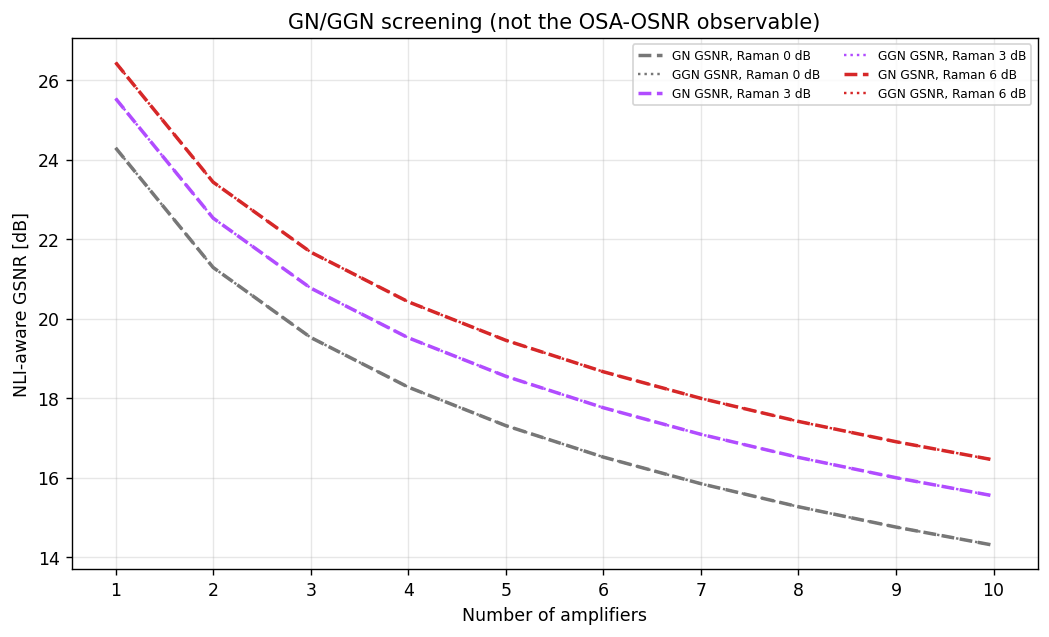

In [5]:
def beta2_ps2_per_km(D, wavelength_nm=1550.0):
    return -(D * wavelength_nm**2) / (2 * np.pi * 299792.458)


def gn_eta_nzdsf(raman_gain_db, samples_per_spacing=100):
    effective_alpha_db = (SPAN_LOSS_DB - raman_gain_db) / SPAN_KM
    alpha = effective_alpha_db * np.log(10) / 20
    beta2 = beta2_ps2_per_km(NZDSF_D)
    spacing_thz = SPACING_HZ / 1e12
    rs_thz = EQUIV_SYMBOL_RATE_HZ / 1e12
    bw_thz = N_CH * spacing_thz
    n = N_CH * samples_per_spacing
    grid = -bw_thz / 2 + (np.arange(n) + 0.5) * bw_thz / n
    f_ch = (np.arange(N_CH) - (N_CH - 1) / 2) * spacing_thz
    target = N_CH // 2 - 1
    f0 = f_ch[target]
    p_ref = 1e-3
    psd = np.zeros_like(grid)
    for fc in f_ch:
        psd[np.abs(grid - fc) < rs_thz / 2] += p_ref / rs_thz
    idx = int(np.argmin(np.abs(grid - f0)))
    i2 = np.zeros_like(grid)
    da = -2 * alpha
    active = np.flatnonzero(psd)
    for j in active:
        db = 1j * 4 * np.pi**2 * (grid[j] - f0) * (grid - f0) * beta2
        kernel = np.abs((1 - np.exp(da * SPAN_KM) * np.exp(db * SPAN_KM)) / (-da - db))**2
        shift = idx - j
        if shift > 0:
            psd3 = np.r_[np.zeros(shift), psd[:-shift]]
        elif shift < 0:
            psd3 = np.r_[psd[-shift:], np.zeros(-shift)]
        else:
            psd3 = psd
        i2[j] = np.trapezoid(kernel * psd[j] * psd * psd3, grid)
    gnli_w_hz = (16/27) * NZDSF_GAMMA**2 * np.trapezoid(i2, grid) * 1e-12
    return gnli_w_hz * EQUIV_SYMBOL_RATE_HZ / p_ref**3


def oscillatory_piecewise_linear_integral(kappa, z, y):
    kappa = np.asarray(kappa, float).ravel()[:, None]
    z0 = z[:-1][None, :]
    dz = np.diff(z)[None, :]
    y0 = y[:, :-1]
    slope = (y[:, 1:] - y[:, :-1]) / dz
    q = 1j * kappa
    q_safe = np.where(np.abs(q) < 1e-14, 1.0 + 0j, q)
    qd = q * dz
    small = np.abs(qd) < 1e-7
    A = np.where(small, dz, np.expm1(qd) / q_safe)
    B = np.where(small, dz**2/2, (np.exp(qd)*(qd-1)+1) / q_safe**2)
    return np.sum(np.exp(q*z0) * (y0*A + slope*B), axis=1)


def ggn_srs_correction_nzdsf(power_dbm, raman_gain_db, z_samples=81, cr=0.028):
    alpha_db = (SPAN_LOSS_DB - raman_gain_db) / SPAN_KM
    alpha = alpha_db * np.log(10) / 20
    beta2 = beta2_ps2_per_km(NZDSF_D)
    spacing_thz = SPACING_HZ / 1e12
    f_ch = (np.arange(N_CH) - (N_CH - 1)/2) * spacing_thz
    target = N_CH//2 - 1
    z = np.linspace(0, SPAN_KM, z_samples)
    leff = (1 - np.exp(-2*alpha*z)) / (2*alpha)
    p = 1e-3 * 10**(power_dbm/10)
    total = N_CH * p
    ranks = np.arange(N_CH)[:, None]
    tilt = np.exp((cr/15.0) * spacing_thz * total * ranks * leff)
    profile = total*np.exp(-2*alpha*z)[None,:]*tilt/(p*tilt.sum(axis=0))[None,:]
    js, ks, thirds = [], [], []
    for j in range(N_CH):
        for k in range(N_CH):
            third = j + k - target
            if 0 <= third < N_CH:
                js.append(j); ks.append(k); thirds.append(third)
    js, ks, thirds = np.asarray(js), np.asarray(ks), np.asarray(thirds)
    kappa = 4*np.pi**2*(f_ch[js]-f_ch[target])*(f_ch[ks]-f_ch[target])*beta2
    ratio = np.sqrt(profile[js]*profile[ks]/profile[thirds]) * np.sqrt(profile[target])
    base = np.repeat(np.exp(-2*alpha*z)[None,:], len(js), axis=0)
    fg = np.abs(oscillatory_piecewise_linear_integral(kappa, z, ratio))**2
    f0 = np.abs(oscillatory_piecewise_linear_integral(kappa, z, base))**2
    return float(fg.sum()/f0.sum())


def ase_per_span_w(raman_gain_db, bandwidth_hz=EQUIV_SYMBOL_RATE_HZ):
    nf_edfa = 10**(EDFA_NF_DB/10)
    gr = 10**(raman_gain_db/10)
    f_hybrid = 1 + (nf_edfa-1)/gr
    total_gain = 10**(SPAN_LOSS_DB/10)
    return f_hybrid * h * (c/LAMBDA_M) * (total_gain-1) * bandwidth_hz


screening_rg = [0, 3, 6]
eta = {rg: gn_eta_nzdsf(rg) for rg in screening_rg}
for rg in screening_rg:
    print(f"Raman {rg} dB: eta_GN={eta[rg]:.1f} 1/W^2")

screening_rows = []
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for color, rg in zip(["#777777", "#b14cff", "#d62728"], screening_rg):
    p_ase = ase_per_span_w(rg)
    p_opt_gn = (p_ase / (2 * eta[rg]))**(1/3)
    p_opt_dbm = 10*np.log10(p_opt_gn/1e-3)
    corr = ggn_srs_correction_nzdsf(p_opt_dbm, rg)
    eta_ggn = eta[rg] * corr
    p_opt_ggn = (p_ase / (2 * eta_ggn))**(1/3)

    gsnr_gn = []
    gsnr_ggn = []
    for n in amp_count:
        gsnr_gn.append(10*np.log10(p_opt_gn / (n*p_ase + n*eta[rg]*p_opt_gn**3)))
        gsnr_ggn.append(10*np.log10(p_opt_ggn / (n*p_ase + n*eta_ggn*p_opt_ggn**3)))
    ax.plot(amp_count, gsnr_gn, color=color, lw=2, ls="--", label=f"GN GSNR, Raman {rg} dB")
    ax.plot(amp_count, gsnr_ggn, color=color, lw=1.4, ls=":", label=f"GGN GSNR, Raman {rg} dB")
    screening_rows.append({
        "Raman gain [dB]": rg,
        "GN optimum launch [dBm/ch]": p_opt_dbm,
        "GGN optimum launch [dBm/ch]": 10*np.log10(p_opt_ggn/1e-3),
        "GGN/GN NLI correction [dB]": 10*np.log10(corr),
        "GN GSNR at N=4 [dB]": gsnr_gn[3],
        "Fig.3 OSA-OSNR at N=4 [dB]": fig3_reference[rg][3],
    })
ax.set(xlabel="Number of amplifiers", ylabel="NLI-aware GSNR [dB]",
       title="GN/GGN screening (not the OSA-OSNR observable)")
ax.set_xticks(amp_count)
ax.legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.show()
display(pd.DataFrame(screening_rows).round(2))

## 결론

1. 논문 Fig. 3은 공개된 cascade/Friis 식으로 매우 가깝게 재현됩니다. 40 GHz filter 가정에서
   Raman gain별 RMSE는 대체로 수십 분의 1 dB 수준입니다.
2. Fig. 7의 L-band gain/NF를 사용한 ASE cascade는 Fig. 9/10의 전체 경향은 설명하지만,
   공개되지 않은 DCF/insertion loss/OPA operating point 때문에 320 km 절대값 오차가 남습니다.
3. GN/GGN screening 값이 measured OSA-OSNR보다 크게 낮은 것은 단순히 “실험이 틀렸다”는 뜻이 아닙니다.
   논문의 dispersion-managed 10G NRZ IM-DD 링크와 GN/GGN의 dispersion-uncompensated coherent
   Gaussian-noise 가정이 맞지 않고, OSA-OSNR가 in-band NLI를 직접 분리하지 못하기 때문입니다.
4. 논문과 정량적으로 맞는 GGN 검증을 하려면 span별 launch power, NZ-DSF $D/\gamma/A_{eff}$,
   DCF map, Raman pump 방향·power profile, 모든 component loss 및 receiver filter bandwidth가 필요합니다.